# Exploratory Data Analysis (EDA) — End-to-End Lecture

**Dataset Required:** Titanic Dataset  
**Download from:** https://www.kaggle.com/datasets/yasserh/titanic-dataset  
**File needed:** `Titanic-Dataset.csv` — place it in the same folder as this notebook.

---

## What is EDA?

Exploratory Data Analysis is the process of **visually and statistically summarizing** a dataset to:
- Understand its structure
- Detect patterns, trends, and anomalies
- Check assumptions before modeling
- Generate hypotheses

---

## EDA Roadmap

```
1. Setup & Imports
2. Load Data
3. First Look (Shape, Dtypes, Head/Tail)
4. Descriptive Statistics
5. Missing Value Analysis
6. Duplicate Detection
7. Univariate Analysis   → Numerical
8. Univariate Analysis   → Categorical
9. Bivariate Analysis    → Num vs Num
10. Bivariate Analysis   → Cat vs Num
11. Bivariate Analysis   → Cat vs Cat
12. Multivariate Analysis (Correlation Heatmap, Pairplot)
13. Outlier Detection
14. Feature Engineering Insights
15. Summary & Key Findings
```

---
## Step 1 — Setup & Imports

We import the standard EDA toolkit:
- `pandas` — data manipulation
- `numpy` — numerical operations
- `matplotlib` — base plotting library
- `seaborn` — statistical visualizations built on top of matplotlib

In [1]:
%pip install pandas matplotlib seaborn numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Plot style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load the Dataset

We load the Titanic CSV into a pandas DataFrame.  
A **DataFrame** is like an Excel table — rows are observations, columns are features.

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')
# print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(df.columns)
df.shape

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


(891, 12)

---
## Step 3 — First Look at the Data

Before anything else, answer these questions:
- How big is the data?
- What columns exist and what are their types?
- What does the first few rows look like?

### 3.1 — Shape

In [4]:
print('Shape (rows, columns):', df.shape)

Shape (rows, columns): (891, 12)


### 3.2 — Column Names & Data Types

> `int64` = whole numbers | `float64` = decimals | `object` = text/string

In [5]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


### 3.3 — First 5 Rows

In [6]:
df.head(n=7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


### 3.4 — Last 5 Rows

In [7]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### 3.5 — Dataset Info (non-null counts + dtype summary)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 3.6 — Column Breakdown

| Column | Description |
|--------|-------------|
| PassengerId | Unique ID |
| Survived | 0 = No, 1 = Yes (Target) |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | Passenger name |
| Sex | male / female |
| Age | Age in years |
| SibSp | # siblings/spouses aboard |
| Parch | # parents/children aboard |
| Ticket | Ticket number |
| Fare | Ticket fare |
| Cabin | Cabin number |
| Embarked | Port: C = Cherbourg, Q = Queenstown, S = Southampton |

---
## Step 4 — Descriptive Statistics

**Descriptive statistics** summarize each column numerically:
- `count` — how many non-null values
- `mean` — average
- `std` — standard deviation (spread)
- `min`, `25%`, `50%`, `75%`, `max` — five-number summary



| Statistic | Meaning                                                                           |
| --------- | --------------------------------------------------------------------------------- |
| **count** | Number of non-missing values in the column.                                       |
| **mean**  | Average value.                                                                    |
| **std**   | Standard deviation; measures how spread out the data is. Higher = more variation. |
| **min**   | Smallest value.                                                                   |
| **25%**   | First quartile (Q1). 25% of values are below this number.                         |
| **50%**   | Median (Q2). Half the values are below and half above.                            |
| **75%**   | Third quartile (Q3). 75% of values are below this number.                         |
| **max**   | Largest value.                                                                    |


### 4.1 — Numerical Columns

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4.2 — Categorical Columns

Pass `include='object'` to get stats for text columns:
- `count` — non-null
- `unique` — number of distinct values
- `top` — most frequent value
- `freq` — frequency of top value

In [10]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


---
## Step 5 — Missing Value Analysis

Missing values (NaN / null) can break models and skew results.  
We must **identify, understand, and handle** them.

### 5.1 — Count Missing Values per Column

In [11]:
missing = df.isnull().sum()
missing = df.isnull()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing
missing_pct

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


### 5.2 — Visualize Missingness

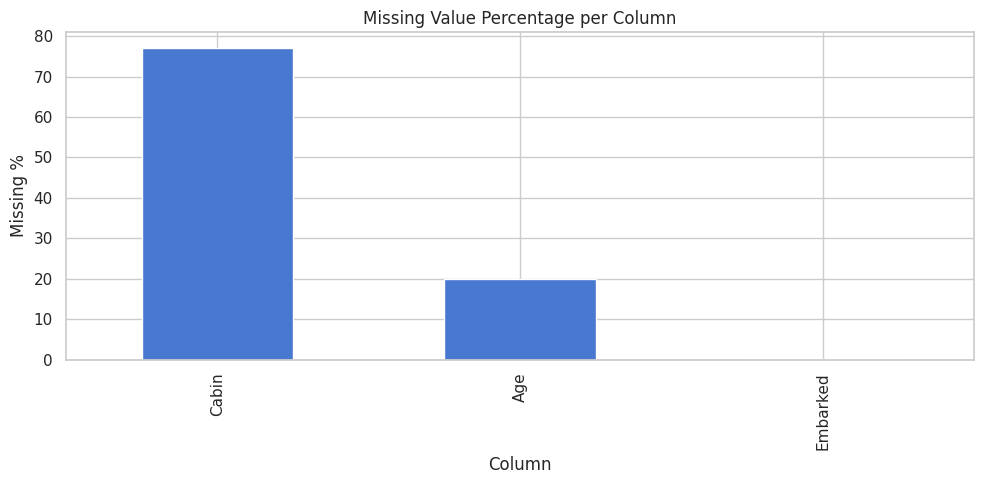

In [12]:
# plt.figure(figsize=(10, 4))
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(
    kind='bar'
)
plt.title('Missing Value Percentage per Column')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 5.3 — Heatmap of Missing Values (pattern view)

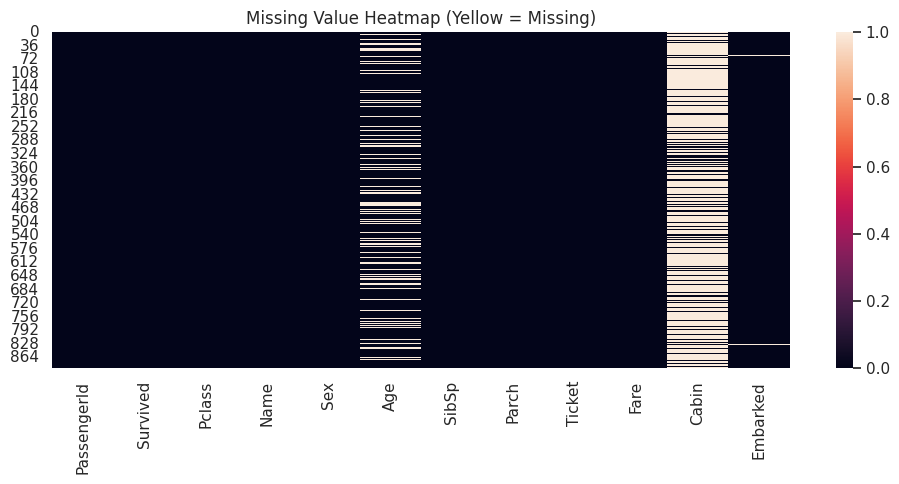

In [13]:
# plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull())
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

### 5.4 — Types of Missingness

| Type | Meaning |
|------|---------|
| **MCAR** — Missing Completely at Random | No pattern; safe to drop rows |
| **MAR** — Missing at Random | Missingness depends on other columns |
| **MNAR** — Missing Not at Random | The missing value itself carries meaning |

For **Cabin**: ~77% missing → likely MNAR (only recorded for higher-class passengers)  
For **Age**: ~20% missing → possibly MAR (younger passengers may have skipped it)  
For **Embarked**: 2 rows missing → MCAR (safe to fill or drop)

---
## Step 6 — Duplicate Detection

Duplicates artificially inflate counts and bias statistics.

In [14]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    print('Duplicate rows:')
    print(df[df.duplicated()])
else:
    print('No duplicates found.')


Number of duplicate rows: 0
No duplicates found.


---
## Step 7 — Univariate Analysis: Numerical Columns

**Univariate** = analyzing one variable at a time.  
For numerical columns we look at:
- Distribution shape (histogram)
- Spread (boxplot)
- Skewness and kurtosis

### 7.1 — Select Numerical Columns

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['PassengerId', 'Survived']]  # remove ID & target
print('Numerical columns:', num_cols)

Numerical columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


### 7.2 — Histograms

A **histogram** shows the frequency distribution of a numerical variable.  
The shape tells us:
- **Normal (bell curve)** — symmetric, mean ≈ median
- **Right-skewed** — long tail on right, mean > median (e.g., Fare)
- **Left-skewed** — long tail on left, mean < median

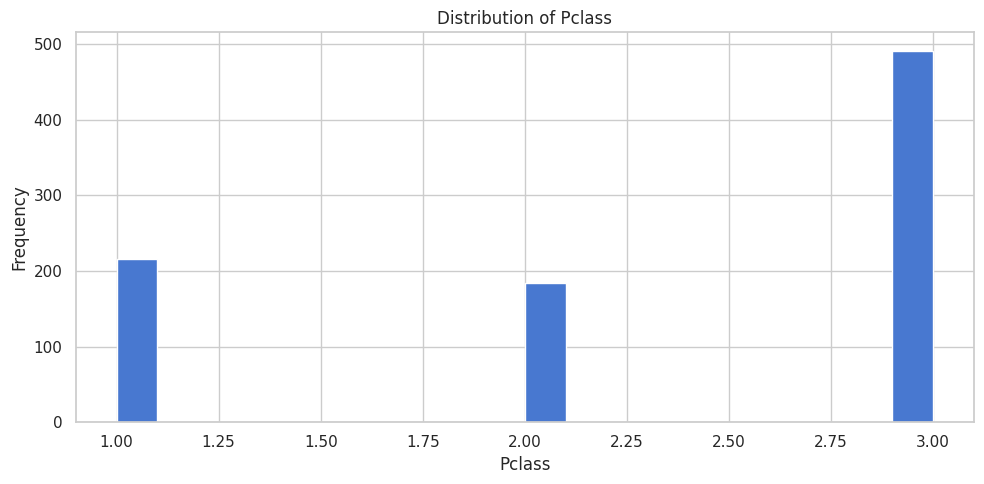

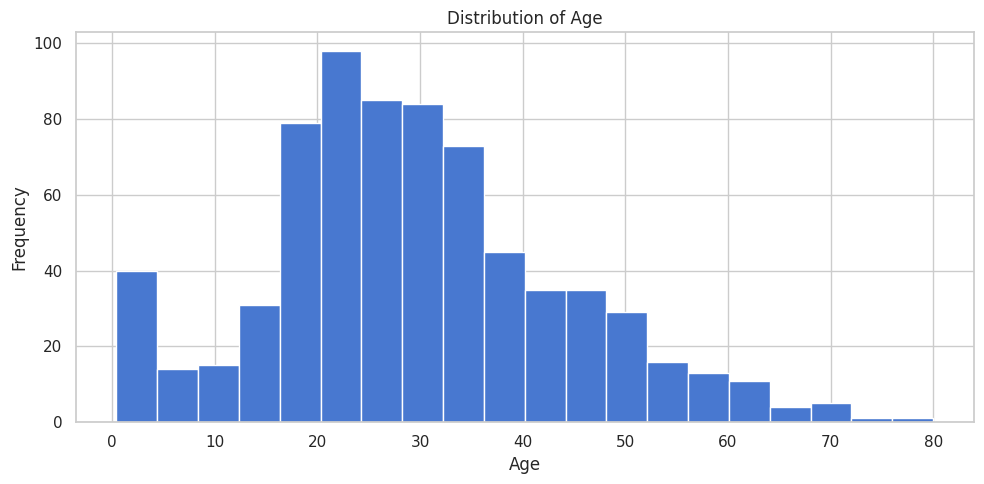

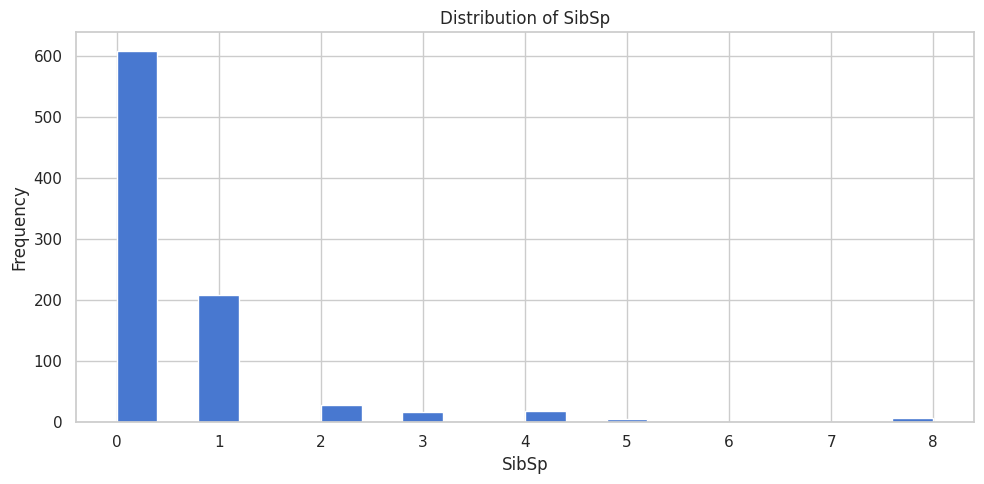

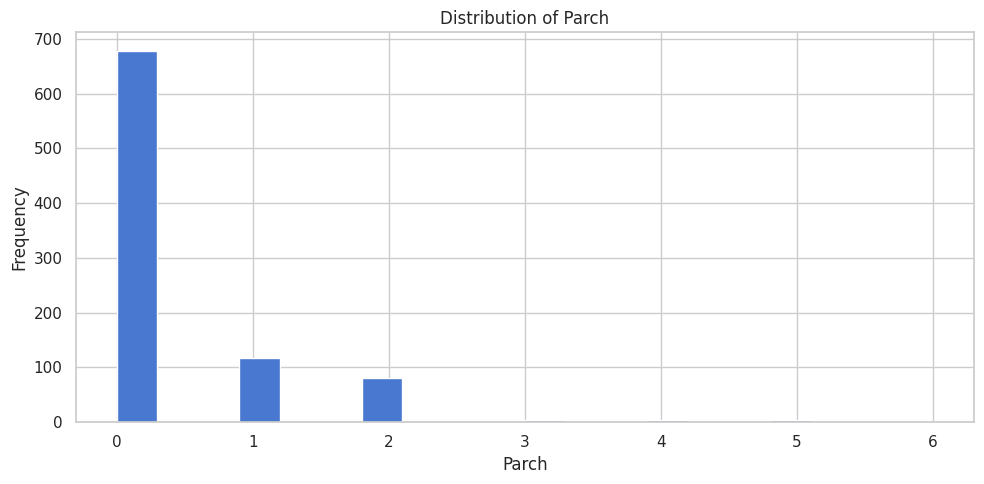

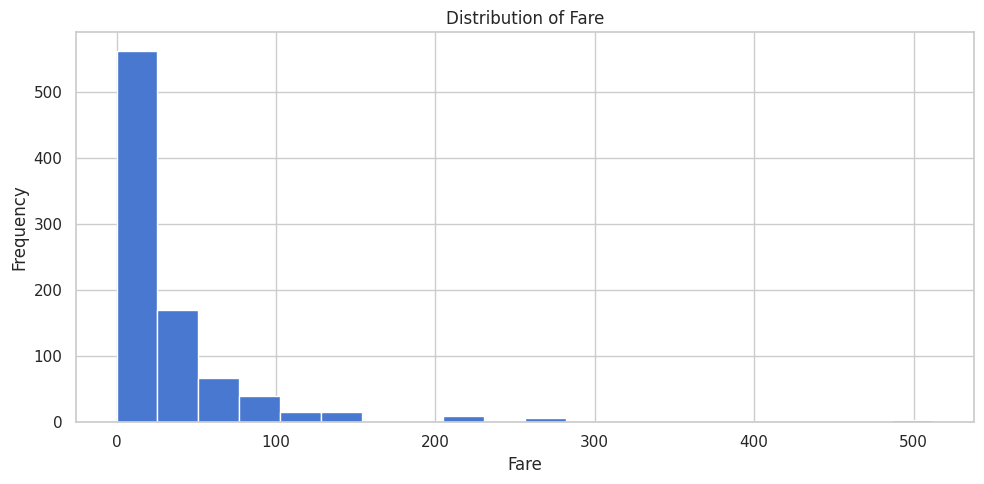

In [17]:
#distributions via matplotlib
for col in num_cols:
    plt.hist(df[col].dropna(), bins=20,)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

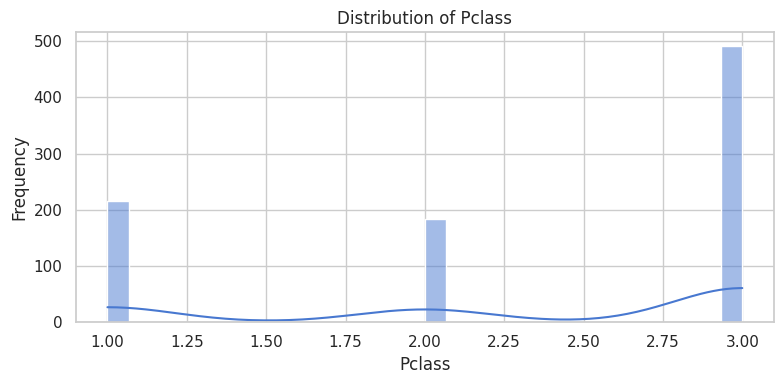

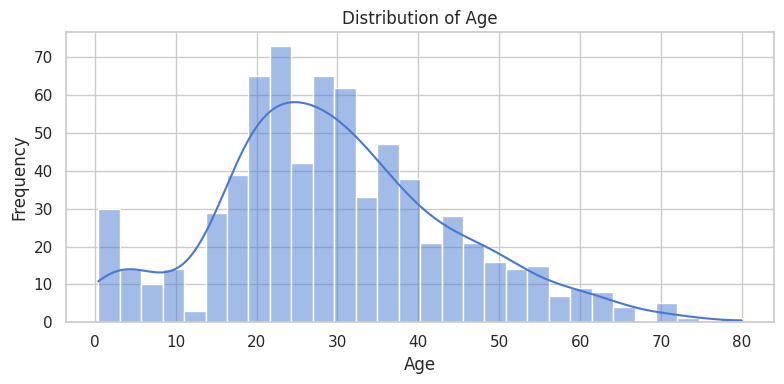

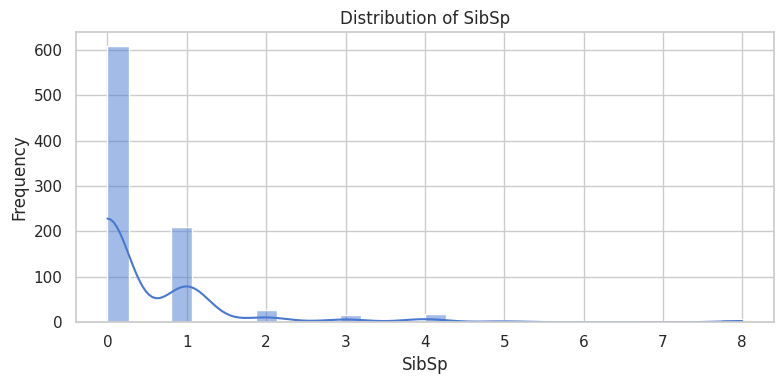

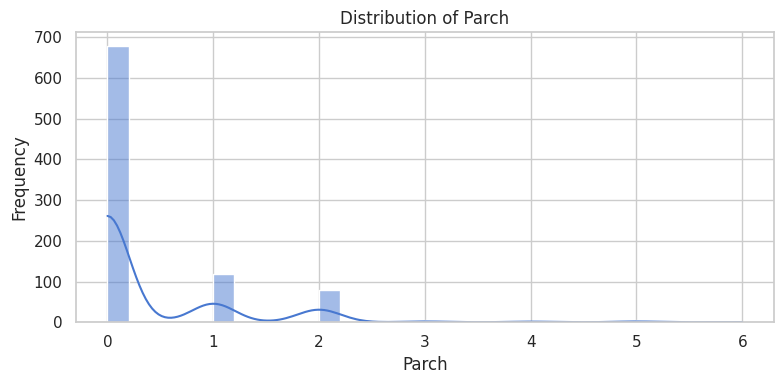

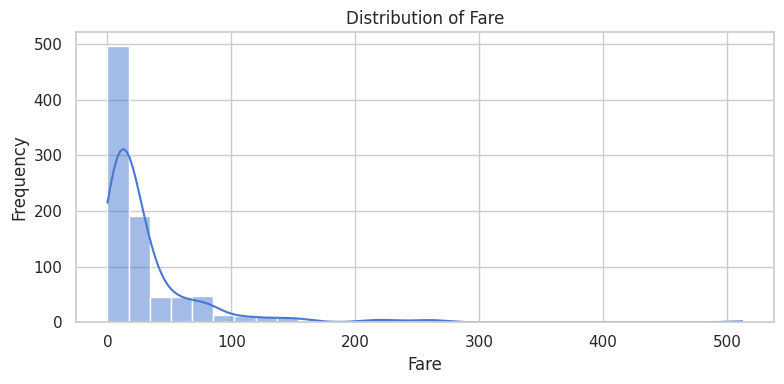

In [18]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### 7.3 — Boxplots

A **boxplot** summarizes a distribution with 5 numbers:
- Minimum (excluding outliers)
- Q1 (25th percentile)
- Median (50th percentile)
- Q3 (75th percentile)
- Maximum (excluding outliers)

Dots **outside the whiskers** are potential **outliers**.

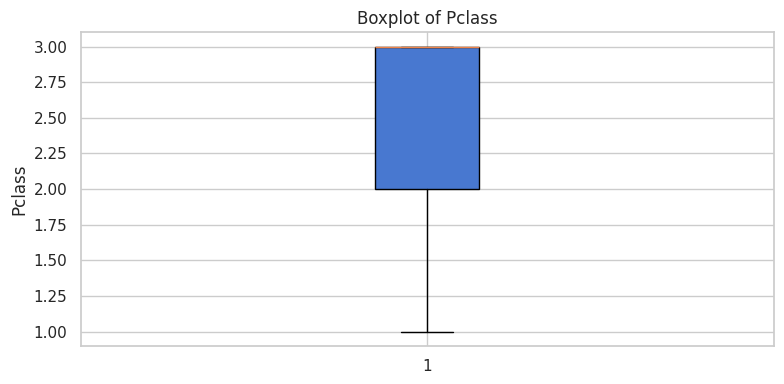

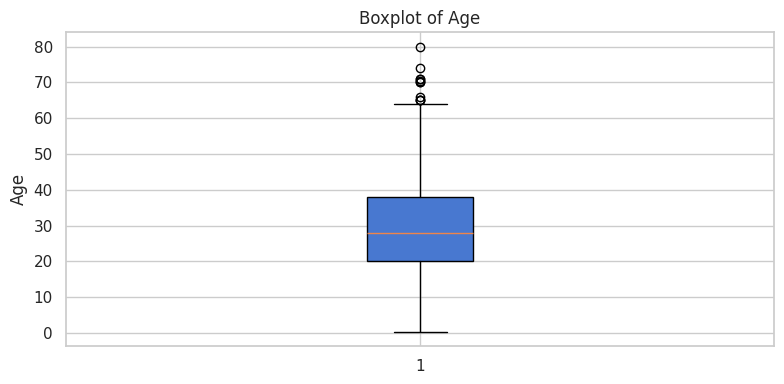

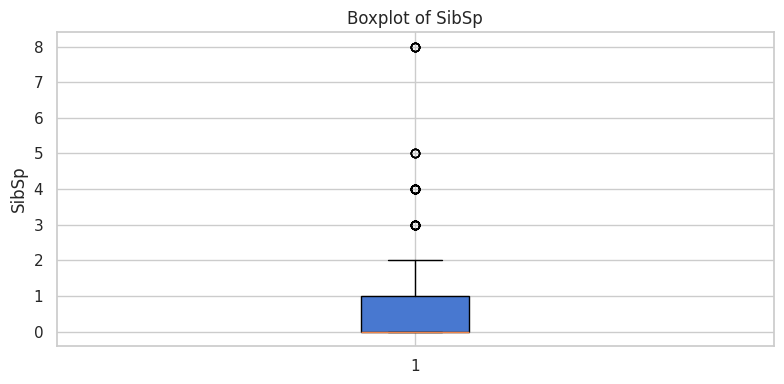

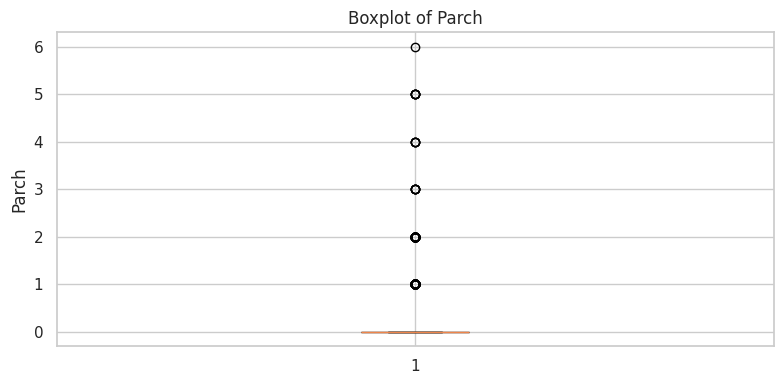

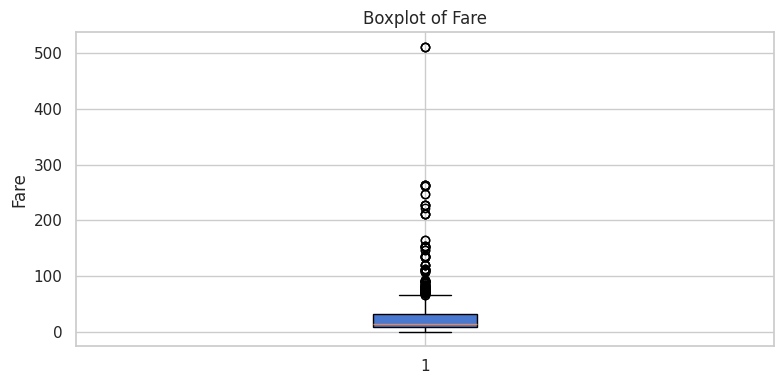

In [19]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 7.4 — Skewness & Kurtosis

- **Skewness**: measures asymmetry of distribution
  - `0` = symmetric
  - `> 0` = right-skewed (tail on right)
  - `< 0` = left-skewed (tail on left)
- **Kurtosis**: measures heaviness of tails
  - `0` = normal tails
  - `> 0` = heavy tails (more extreme values)
  - `< 0` = light tails

![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

In [20]:
stats_df = pd.DataFrame({
    'Mean': df[num_cols].mean().round(2),
    'Median': df[num_cols].median().round(2),
    'Std': df[num_cols].std().round(2),
    'Skewness': df[num_cols].skew().round(2),
    'Kurtosis': df[num_cols].kurt().round(2)
})
stats_df

,Mean,Median,Std,Skewness,Kurtosis
Pclass,2.31,3.00,0.84,-0.63,-1.28
Age,29.70,28.00,14.53,0.39,0.18
SibSp,0.52,0.00,1.10,3.70,17.88
Parch,0.38,0.00,0.81,2.75,9.78
Fare,32.20,14.45,49.69,4.79,33.40


---
## Step 8 — Univariate Analysis: Categorical Columns

For categorical columns we use:
- **Value counts** — frequency of each category
- **Bar chart** — visual count comparison
- **Pie chart** — proportional view

### 8.1 — Select Categorical Columns

In [21]:
cat_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']
print('Categorical columns to analyze:', cat_cols)

Categorical columns to analyze: ['Survived', 'Pclass', 'Sex', 'Embarked']


### 8.2 — Value Counts for Each Category

In [22]:
for col in cat_cols:
  print(df[col].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


### 8.3 — Bar Charts

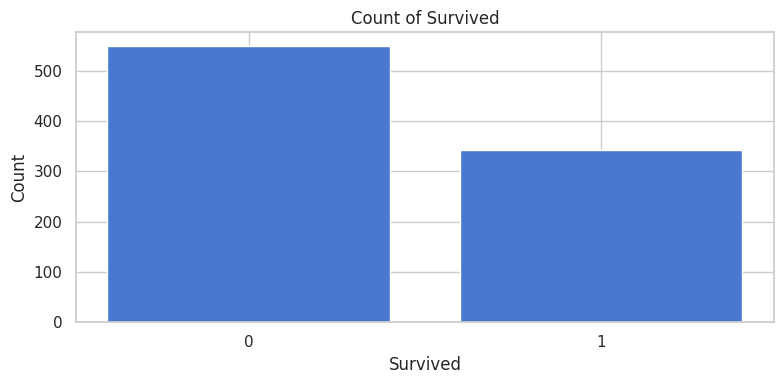

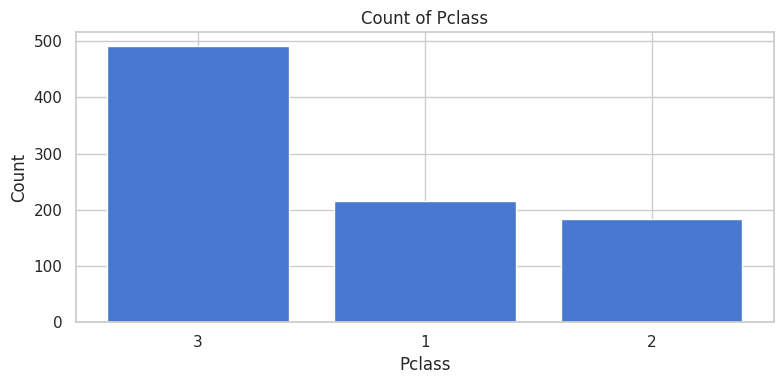

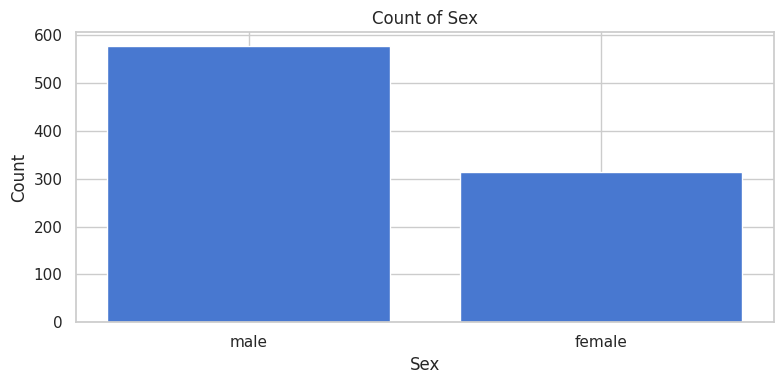

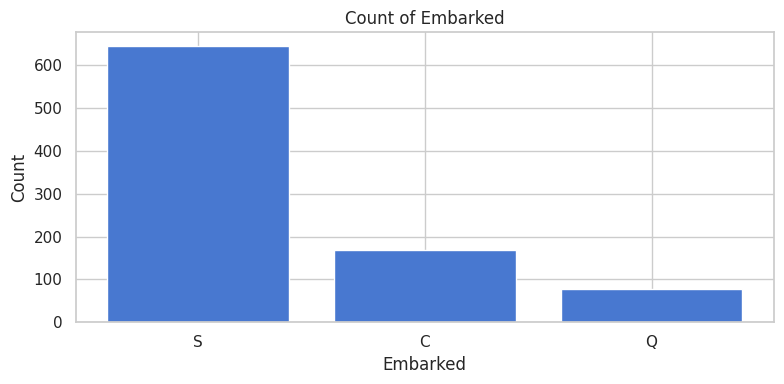

In [23]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    counts = df[col].value_counts()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

### 8.4 — Pie Chart for Target Variable (Survived)

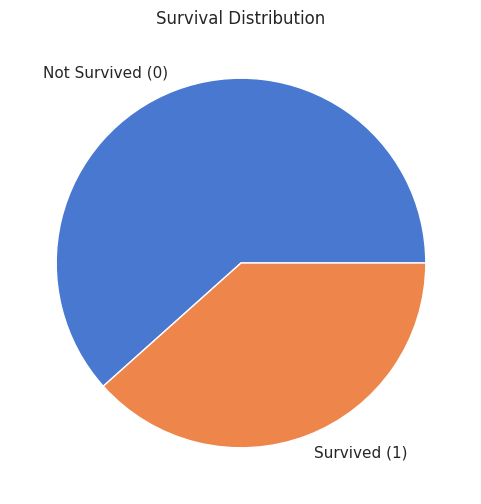

In [24]:
survived_counts = df['Survived'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    survived_counts,
    labels=['Not Survived (0)', 'Survived (1)'],
)
plt.title('Survival Distribution')
plt.show()

---
## Step 9 — Bivariate Analysis: Numerical vs Numerical

**Bivariate** = analyzing the relationship between two variables.  

For two numerical columns, we use:
- **Scatter plot** — visualize direction and strength of relationship
- **Correlation coefficient** — quantify linear relationship (-1 to +1)

### 9.1 — Scatter Plot: Age vs Fare

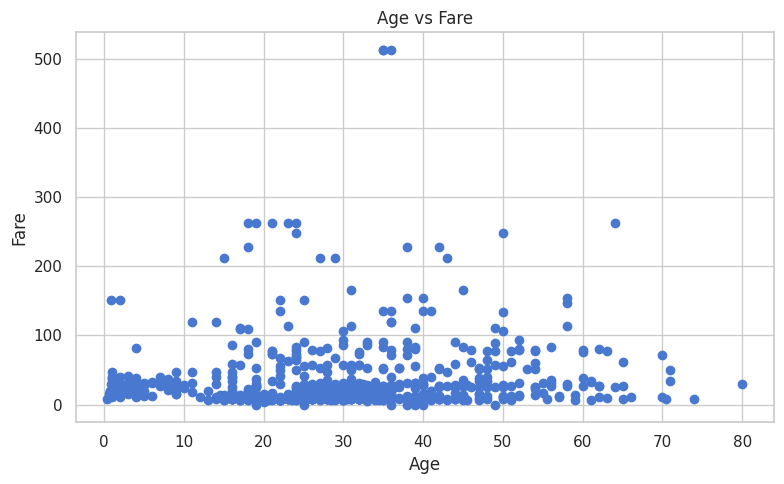

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Fare'])
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

### 9.2 — Regression Plot (with trend line)

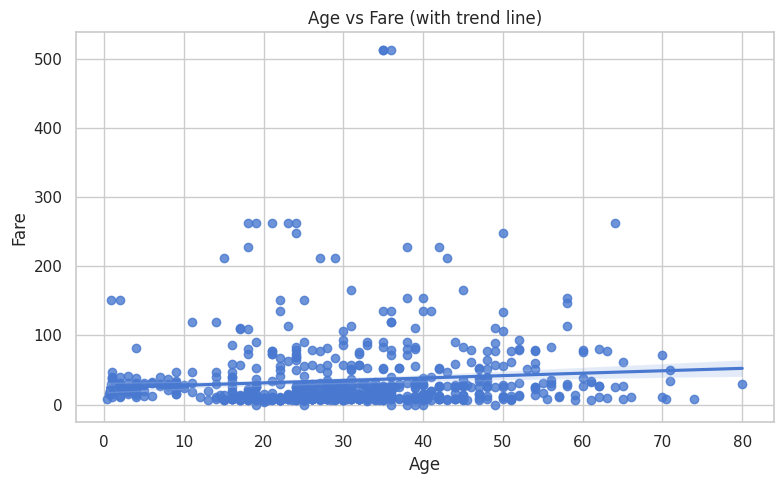

In [26]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Age', y='Fare')
plt.title('Age vs Fare (with trend line)')
plt.tight_layout()
plt.show()

# Correlation

## What is Correlation?

Correlation measures the **strength** and **direction** of the relationship between two variables.

- Ranges from **-1 to +1**
- Tells how much one variable changes when another changes

| Value | Meaning |
|---------|---------|
| +1 | Perfect positive correlation |
| 0 | No correlation |
| -1 | Perfect negative correlation |

---

# Types of Correlation

## 1. Pearson Correlation

Most commonly used.

### Formula

$$
r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}
$$

### Characteristics

- Measures **linear relationship**
- Assumes data is **normally distributed**
- Sensitive to **outliers**
- Works best with **continuous numerical data**

### Python

```python
df.corr(method='pearson')
```

---

## 2. Spearman Correlation

### Formula

$$
r_s = 1 - \frac{6\sum d_i^2}{n(n^2 - 1)}
$$

Where:

- $d_i$ = difference between ranks of each pair

### Characteristics

- Measures **monotonic relationship** (not necessarily linear)
- Works on **ranked data**
- Less affected by **outliers**
- Suitable for **ordinal** or **non-normal** data

### Python

```python
df.corr(method='spearman')
```

---

## 3. Kendall Correlation

### Formula

$$
\tau = \frac{(C - D)}
{\frac{1}{2}n(n-1)}
$$

Where:

- $C$ = number of concordant pairs
- $D$ = number of discordant pairs

### Characteristics

- Rank-based like Spearman
- More robust for **small datasets**
- Slower to compute
- Less commonly used

### Python

```python
df.corr(method='kendall')
```

---

# Comparison Table

| Feature | Pearson | Spearman | Kendall |
|----------|----------|----------|----------|
| Relationship Type | Linear | Monotonic | Monotonic |
| Data Type | Continuous | Ordinal / Continuous | Ordinal / Continuous |
| Normal Distribution Needed | Yes | No | No |
| Sensitive to Outliers | Yes | No | No |
| Small Datasets | Average | Average | Best |
| Speed | Fast | Medium | Slow |
| Most Used | ✅ Yes | ✅ Yes | Rarely |

---

# What We Generally Use

- **Pearson** → Default choice for numerical data with no major outliers
- **Spearman** → When data contains outliers or is not normally distributed
- **Kendall** → Rarely used, mainly for very small datasets

---

# Interpreting Correlation Values

| Correlation Range | Strength |
|------------------|------------|
| 0.9 to 1.0 | Very Strong |
| 0.7 to 0.9 | Strong |
| 0.5 to 0.7 | Moderate |
| 0.3 to 0.5 | Weak |
| 0.0 to 0.3 | Very Weak / Negligible |

> The same ranges apply for negative values.  
> Example: **-0.9 to -1.0** indicates a very strong negative correlation.

---

# Correlation Heatmap in Python

```python
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(method='pearson'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()
```

---

# Rule of Thumb

✅ Use **Pearson** by default.

✅ Switch to **Spearman** if:

- Data contains significant outliers
- Data is skewed
- Relationship is monotonic but not necessarily linear

✅ Use **Kendall** mainly for very small datasets or when a more robust rank-based measure is preferred.

### 9.3 — Correlation Matrix

**Pearson correlation** measures linear relationship:  
- `+1` = perfect positive correlation  
- `-1` = perfect negative correlation  
- `0` = no linear relationship  

Rule of thumb:
- |r| > 0.7 → strong
- 0.4 < |r| < 0.7 → moderate
- |r| < 0.4 → weak

In [27]:
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(2))

          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
Age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp        -0.04    0.08 -0.31   1.00   0.41  0.16
Parch         0.08    0.02 -0.19   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00


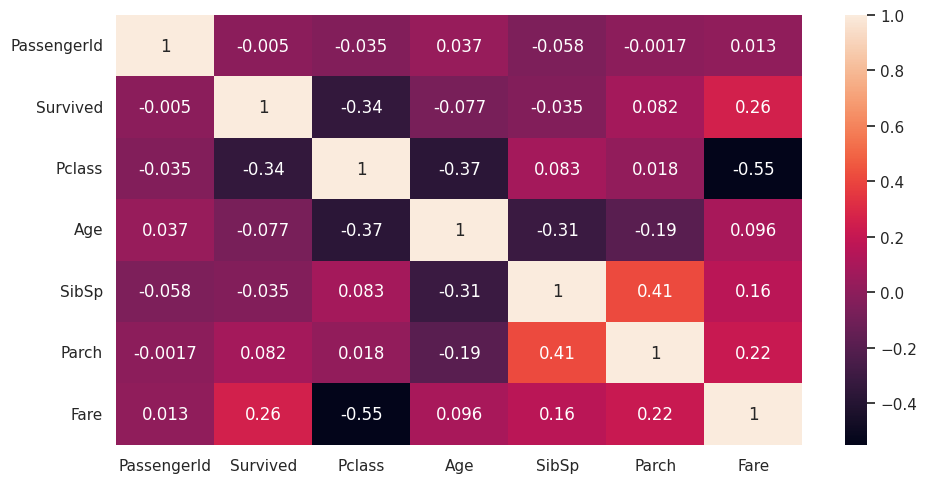

In [28]:
# plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(method='pearson', numeric_only=True),annot=True)
# plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
## Step 10 — Bivariate Analysis: Categorical vs Numerical

How does a categorical variable (e.g., Sex, Pclass) affect a numerical variable (e.g., Age, Fare)?

Best tools:
- **Boxplot** — compare distributions side-by-side
- **Violin plot** — shows distribution shape inside the box
- **Bar chart of means** — quick comparison

### 10.1 — Fare by Passenger Class (Boxplot)

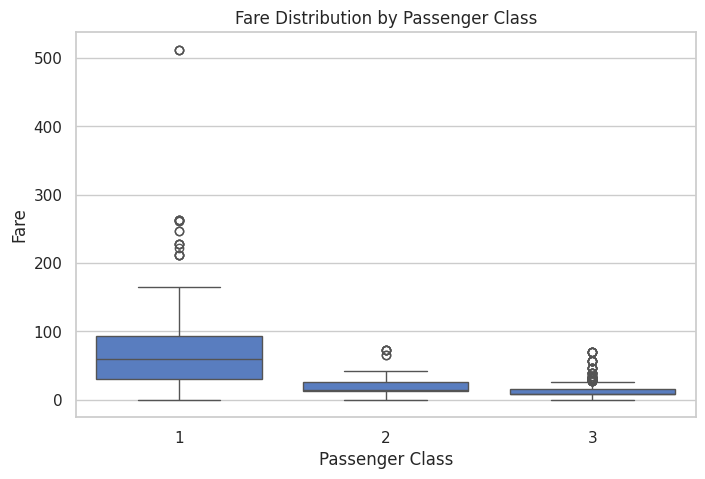

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

### 10.2 — Age by Sex (Violin Plot)

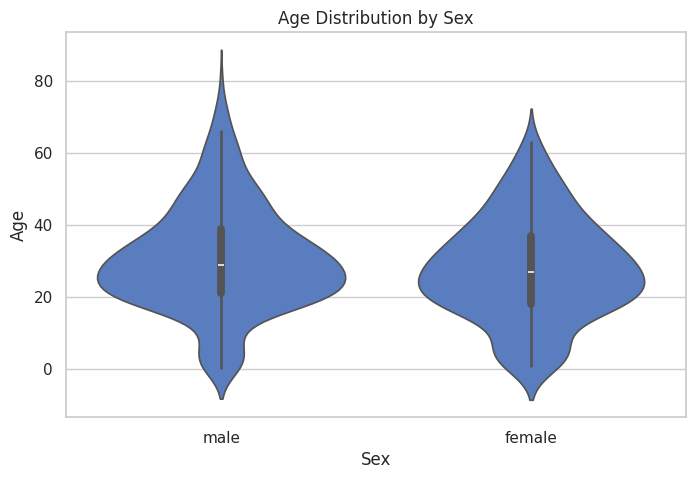

In [30]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Sex', y='Age')
plt.title('Age Distribution by Sex')
plt.show()

# Male (left):

# Wider in the 20–40 range → most males were young adults
# Long tail going up to ~88 → some very old males
# Slightly pointed at bottom → fewer very young males
# Median around 28–30
# Female (right):

# Also wide in 20–40 range
# Max age around ~72 → fewer very old females than males
# More symmetric shape than males
# Median around 27–28

---
## Step 11 — Bivariate Analysis: Categorical vs Categorical

How do two categorical variables relate to each other?

Best tools:
- **Crosstab (contingency table)** — frequency counts
- **Stacked/grouped bar chart** — visual comparison
- **Heatmap of crosstab** — easy to spot patterns

### 11.1 — Crosstab: Sex vs Survived

In [31]:
ct = pd.crosstab(df['Sex'], df['Survived'], margins=True)
ct.columns = ['Not Survived', 'Survived', 'Total']
print(ct)

        Not Survived  Survived  Total
Sex                                  
female            81       233    314
male             468       109    577
All              549       342    891


### 11.3 — Grouped Bar Chart: Pclass vs Survived

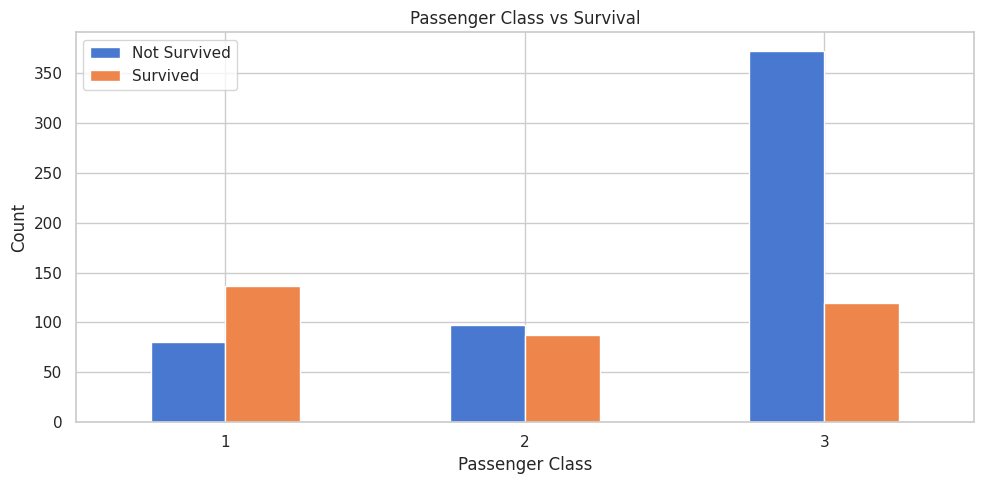

In [32]:
ct2 = pd.crosstab(df['Pclass'], df['Survived'])

ct2.plot(kind='bar')
plt.title('Passenger Class vs Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()

---
## Step 12 — Multivariate Analysis

**Multivariate** = analyzing 3 or more variables simultaneously.

### 12.1 — Correlation Heatmap

Shows pairwise correlations for all numerical columns at once.

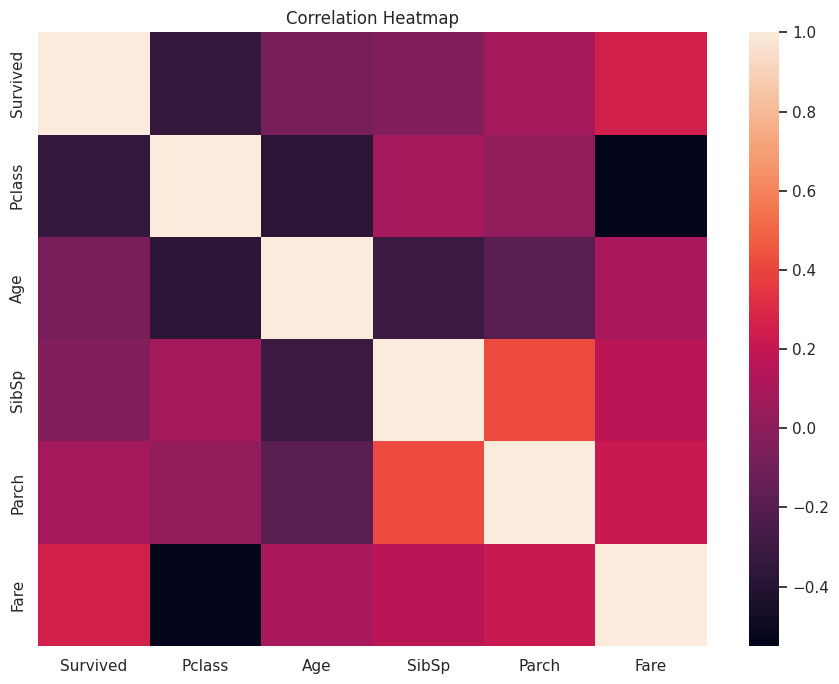

In [33]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## Step 13 — Outlier Detection

An **outlier** is a data point significantly different from others.  
Outliers can be:
- **Errors** (typos, measurement issues) → should be removed
- **Genuine extremes** (a very high fare) → may need special treatment

### Method 1 — IQR (Interquartile Range) Rule

```
IQR = Q3 - Q1
Lower fence = Q1 - 1.5 × IQR
Upper fence = Q3 + 1.5 × IQR
Outliers = values below Lower or above Upper fence
```

In [34]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    outliers, low, high = detect_outliers_iqr(df[col].dropna())
    print(f'{col}: {len(outliers)} outliers | Range: [{low:.1f}, {high:.1f}]')

Age: 11 outliers | Range: [-6.7, 64.8]
Fare: 116 outliers | Range: [-26.7, 65.6]
SibSp: 46 outliers | Range: [-1.5, 2.5]
Parch: 213 outliers | Range: [0.0, 0.0]


### 13.3 — Visualize Outliers in Fare

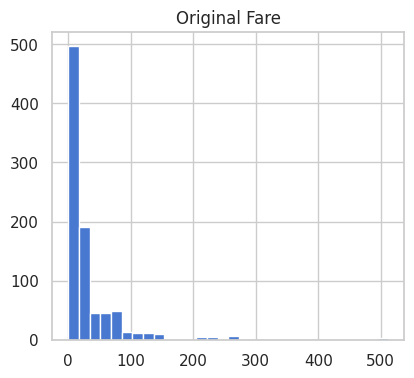

In [35]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].hist(df['Fare'].dropna(), bins=50, color='steelblue', edgecolor='black')
# axes[0].set_title('Fare Distribution (original)')
# axes[0].set_xlabel('Fare')

# axes[1].hist(np.log1p(df['Fare'].dropna()), bins=50, color='teal', edgecolor='black')
# axes[1].set_title('Fare Distribution (log-transformed)')
# axes[1].set_xlabel('log(1 + Fare)')

# plt.suptitle('Log Transformation Reduces Right Skew & Outlier Impact')
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['Fare'].dropna(), bins=30)
plt.title('Original Fare')

# plt.subplot(1,2,2)
# plt.hist(np.log1p(df['Fare'].dropna()), bins=30)
# plt.title('Log Fare')

plt.show()

---
## Step 14 — Feature Engineering Insights from EDA

EDA often reveals opportunities for new features that can improve models.

### 14.1 — Family Size (SibSp + Parch + 1)

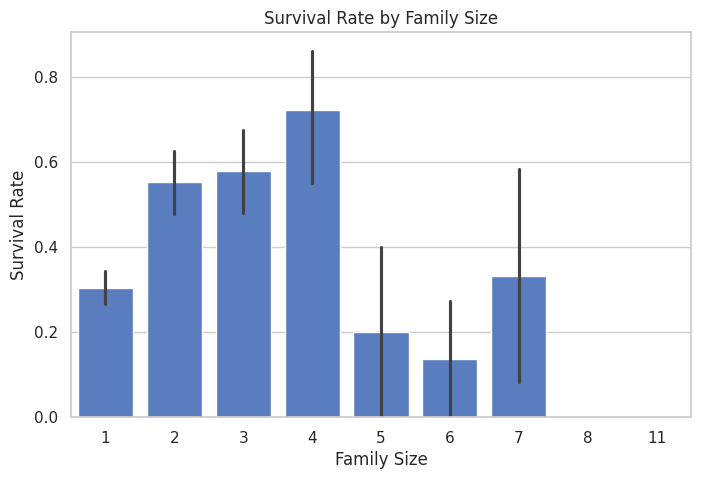

In [36]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='FamilySize', y='Survived')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

---
## Step 15 — Summary & Key Findings

### What we found from Titanic EDA:

In [37]:
print('=== EDA Summary: Titanic Dataset ===')
print(f'Total passengers: {len(df)}')
print(f'Overall survival rate: {df["Survived"].mean():.1%}')
print()
print('--- By Sex ---')
print(df.groupby('Sex')['Survived'].mean().apply(lambda x: f'{x:.1%}'))
print()
print('--- By Class ---')
print(df.groupby('Pclass')['Survived'].mean().apply(lambda x: f'{x:.1%}'))
print()
print('--- Missing Values ---')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('--- Engineered Features ---')
print(f'FamilySize range: {df["FamilySize"].min()} to {df["FamilySize"].max()}')

=== EDA Summary: Titanic Dataset ===
Total passengers: 891
Overall survival rate: 38.4%

--- By Sex ---
Sex
female    74.2%
male      18.9%
Name: Survived, dtype: object

--- By Class ---
Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object

--- Missing Values ---
Age         177
Cabin       687
Embarked      2
dtype: int64

--- Engineered Features ---
FamilySize range: 1 to 11


### Key Takeaways

| Finding | Insight |
|---------|----------|
| **Females survived ~74%** vs Males ~19% | Sex is the strongest predictor |
| **1st class survived ~63%** vs 3rd class ~24% | Socioeconomic status matters |
| **Children (age < 12) highest survival** | Age and class together matter |
| **Fare is highly right-skewed** | Log transform needed before modeling |
| **Cabin has 77% missing** | Either drop or create "has_cabin" binary |
| **Age has 20% missing** | Impute using median by title group |
| **Family size 2-4 survives best** | Isolated solo travelers do worse |
| **Pclass and Fare are highly correlated** | Multicollinearity — pick one |

---

## EDA Checklist

```
✅ Load data and understand shape
✅ Check column names and data types
✅ Compute descriptive statistics
✅ Identify and visualize missing values
✅ Find and remove duplicates
✅ Univariate analysis (numerical + categorical)
✅ Bivariate analysis (Num-Num, Cat-Num, Cat-Cat)
✅ Multivariate analysis (heatmap, pairplot, facetgrid)
✅ Detect outliers (IQR + Z-score)
✅ Engineer new features based on findings
✅ Document key findings
```

---
*After EDA → next steps are Data Cleaning, Feature Engineering, and then Model Building.*

---

## Data Preprocessing — Making Data ML-Ready

EDA told us *what* the data looks like. Now we fix it and shape it so a model can learn from it.

| Step | Task |
|------|------|
| 1 | Extract `Title` from `Name` (before dropping it) |
| 2 | Drop irrelevant columns |
| 3 | Impute missing values (`Age`, `Embarked`) |
| 4 | Feature engineering (`FamilySize`, `IsAlone`) |
| 5 | Encode categoricals (`Sex`, `Embarked`, `Title`) |
| 6 | Train / Test split |
| 7 | Feature scaling |

### Step 1 — Extract Title from Name

The `Name` column hides a **Title** (Mr, Mrs, Miss, Master…) which is a strong predictor.  
We pull it out with regex **before** dropping the Name column.

In [38]:
# Start fresh from the raw CSV — clean preprocessing pipeline
df_ml = pd.read_csv('Titanic-Dataset.csv')

# ── Step 1: Extract Title from Name (must happen BEFORE dropping Name)
df_ml['Title'] = df_ml['Name'].str.extract(r',\s*([^\.]+)\.')

# Group uncommon titles to reduce cardinality
title_map = {
    'Mr': 'Mr',      'Miss': 'Miss',    'Mrs': 'Mrs',   'Master': 'Master',
    'Mlle': 'Miss',  'Ms': 'Miss',      'Mme': 'Mrs',
    'Dr': 'Rare',    'Rev': 'Rare',     'Col': 'Rare',  'Major': 'Rare',
    'Countess': 'Rare', 'Lady': 'Rare', 'Sir': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare',  'Dona': 'Rare', 'Capt': 'Rare'
}
df_ml['Title'] = df_ml['Title'].str.strip().map(title_map).fillna('Rare')

print('Title value counts:')
print(df_ml['Title'].value_counts())

Title value counts:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [51]:
df["Name"]

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


### Step 2 — Drop Irrelevant Columns

| Column | Reason to Drop |
|--------|---------------|
| `PassengerId` | Just a row index — zero predictive value |
| `Name` | Title already extracted; raw name is noise |
| `Ticket` | High cardinality, no consistent pattern |
| `Cabin` | 77% missing — too sparse to use directly |

In [54]:
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_ml.drop(columns=cols_to_drop, inplace=True)

print('Remaining columns:', df_ml.columns.tolist())
print('Shape:', df_ml.shape)

KeyError: "['PassengerId', 'Name', 'Ticket', 'Cabin'] not found in axis"

### Step 3 — Handle Missing Values

| Column | % Missing | Strategy | Why |
|--------|:---------:|----------|-----|
| `Embarked` | 0.2% | Fill with **mode** | Only 2 rows; most common port (S) is safe |
| `Age` | 19.9% | Fill with **median per Title group** | Title correlates with age (Master = boy, Mr = adult) |
| `Cabin` | 77% | Already dropped | Too sparse to impute meaningfully |

In [56]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [40]:
print("Missing values BEFORE imputation:")
print(df_ml.isnull().sum()[df_ml.isnull().sum() > 0])
print()

# Embarked: fill with most common port
df_ml['Embarked'] = df_ml['Embarked'].fillna(
    df_ml['Embarked'].mode()[0]
)

# Age: fill with overall median age
df_ml['Age'] = df_ml['Age'].fillna(
    df_ml['Age'].median()
)

print("Missing values AFTER imputation:")
print(df_ml.isnull().sum())

Missing values BEFORE imputation:
Age         177
Embarked      2
dtype: int64

Missing values AFTER imputation:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
dtype: int64


In [60]:
mode=df["Embarked"].mode()

### Step 4 — Feature Engineering

Create new features that encode additional signal:

| Feature | Formula | Insight from EDA |
|---------|---------|-----------------|
| `FamilySize` | SibSp + Parch + 1 | Family groups of 2-4 had higher survival |
| `IsAlone` | FamilySize == 1 | Solo travellers had lower survival |

We then **drop** `SibSp` and `Parch` since `FamilySize` captures both.

In [41]:
# FamilySize = self + siblings/spouses + parents/children
df_ml['FamilySize'] = df_ml['SibSp'] + df_ml['Parch'] + 1

# IsAlone: 1 if travelling solo, 0 if with family
df_ml['IsAlone'] = (df_ml['FamilySize'] == 1).astype(int)

# SibSp and Parch are now captured by FamilySize — drop them
df_ml.drop(columns=['SibSp', 'Parch'], inplace=True)

print('New features created:')
print(df_ml[['FamilySize', 'IsAlone']].value_counts())

New features created:
FamilySize  IsAlone
1           1          537
2           0          161
3           0          102
4           0           29
6           0           22
5           0           15
7           0           12
11          0            7
8           0            6
Name: count, dtype: int64


### Step 5 — Encode Categorical Variables

ML models require **numeric input** — text columns must be converted.

| Column | Method | Reason |
|--------|--------|--------|
| `Sex` | Binary map (male=0, female=1) | Only 2 values — simple and efficient |
| `Embarked` | One-Hot Encoding | 3 unordered categories (C, Q, S) |
| `Title` | One-Hot Encoding | 5 unordered categories |

> **`drop_first=True`** removes one dummy column per group to avoid the **dummy variable trap** (perfect multicollinearity).

In [42]:
# Binary encode Sex
df_ml['Sex'] = df_ml['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked and Title (drop_first avoids the dummy variable trap)
df_ml = pd.get_dummies(df_ml, columns=['Embarked', 'Title'], drop_first=True)

# Convert any boolean columns to int (pandas get_dummies returns bool in newer versions)
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

print('Shape after encoding:', df_ml.shape)
print('Columns:', df_ml.columns.tolist())
print()
print(f'Missing values remaining: {df_ml.isnull().sum().sum()}  ✅ Clean!')
df_ml.head(3)

Shape after encoding: (891, 13)
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

Missing values remaining: 0  ✅ Clean!


,Survived,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,7.2500,2,0,0,1,0,1,0,0
1,1,1,1,38.0,71.2833,2,0,0,0,0,0,1,0
2,1,3,1,26.0,7.9250,1,1,0,1,1,0,0,0


### Step 7 — Feature Selection & Train / Test Split

- **X** = all columns except `Survived` (the features the model learns from)
- **y** = `Survived` column (the label / target to predict)
- **80% train / 20% test** is a standard split
- `stratify=y` ensures the same survival ratio in both splits (important for imbalanced data)

In [43]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('Survived', axis=1)
y = df_ml['Survived']

# stratify=y keeps the same Survived ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} rows  |  Survived: {y_train.mean():.1%}')
print(f'Test set     : {X_test.shape[0]} rows  |  Survived: {y_test.mean():.1%}')
print(f'Features     : {X_train.shape[1]}')

Training set : 712 rows  |  Survived: 38.3%
Test set     : 179 rows  |  Survived: 38.5%
Features     : 12


In [44]:
X_train

,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
692,3,0,28.0,56.4958,1,1,0,1,0,1,0,0
481,2,0,28.0,0.0000,1,1,0,1,0,1,0,0
527,1,0,28.0,221.7792,1,1,0,1,0,1,0,0
855,3,1,18.0,9.3500,2,0,0,1,0,0,1,0
801,2,1,31.0,26.2500,3,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
359,3,1,28.0,7.8792,1,1,1,0,1,0,0,0
258,1,1,35.0,512.3292,1,1,0,0,1,0,0,0
736,3,1,48.0,34.3750,5,0,0,1,0,0,1,0
462,1,0,47.0,38.5000,1,1,0,1,0,1,0,0


### Step 8 — Feature Scaling

Many algorithms (especially Logistic Regression) are sensitive to the **magnitude** of features.  
`StandardScaler` transforms each feature to **mean = 0, std = 1**.

> **Critical rule:** Fit the scaler **only on training data**, then apply the same transform to the test set.  
> Fitting on the full dataset would leak test information into training — called **data leakage**.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ON train, then transform
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print(f'X_train mean (should be ~0): {X_train_scaled.mean():.6f}')
print(f'X_train std  (should be ~1): {X_train_scaled.std():.6f}')

Scaling complete.
X_train mean (should be ~0): 0.000000
X_train std  (should be ~1): 1.000000


---

## Model Building & Evaluation

We train **3 models** of increasing complexity and compare them:

| Model | Needs Scaling? | Key Characteristic |
|-------|:--------------:|--------------------|
| Logistic Regression | ✅ Yes | Linear boundary, fast, interpretable baseline |
| Decision Tree | ❌ No | Captures non-linearity, easy to visualise |
| Random Forest | ❌ No | Ensemble of trees — high accuracy, robust |

**Evaluation metrics:**

| Metric | What it answers |
|--------|----------------|
| **Accuracy** | What % of predictions were correct overall? |
| **Precision** | Of those predicted as Survived, how many truly survived? |
| **Recall** | Of those who truly survived, how many did we catch? |
| **F1-Score** | Balance between Precision and Recall |
| **Confusion Matrix** | Where exactly did the model go right/wrong? |

### Model 1 — Logistic Regression

A statistical model that estimates the **probability** of an outcome.  
- Works best with **linearly separable** data  
- **Requires** feature scaling (sensitive to magnitude)  
- Fast and highly interpretable — great baseline

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train on scaled data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Not Survived', 'Survived']))

=== Logistic Regression ===
Accuracy: 0.8492

              precision    recall  f1-score   support

Not Survived       0.86      0.90      0.88       110
    Survived       0.83      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



### Model 2 — Decision Tree Classifier

A tree that asks a series of yes/no questions to reach a prediction.  
- Captures **non-linear** relationships  
- Easy to visualize and explain  
- Prone to overfitting → controlled here with `max_depth=5`  
- Does **not** require feature scaling

In [47]:
from sklearn.tree import DecisionTreeClassifier

# Tree-based models do NOT need scaling — use unscaled X_train / X_test
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print('=== Decision Tree ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['Not Survived', 'Survived']))

=== Decision Tree ===
Accuracy: 0.7989

              precision    recall  f1-score   support

Not Survived       0.79      0.92      0.85       110
    Survived       0.82      0.61      0.70        69

    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179



### Model 3 — Random Forest Classifier

An **ensemble** of many decision trees.  
Each tree votes; the majority vote wins.  
- Reduces overfitting compared to a single tree  
- Provides feature importance scores  
- Does **not** require scaling

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Tree-based models do NOT need scaling
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Not Survived', 'Survived']))

=== Random Forest ===
Accuracy: 0.8268

              precision    recall  f1-score   support

Not Survived       0.83      0.91      0.87       110
    Survived       0.83      0.70      0.76        69

    accuracy                           0.83       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179



---

## Final Summary — End-to-End Pipeline

```
Raw CSV
  → EDA          (understand, visualize, find patterns)
  → Preprocessing (clean, engineer, encode)
  → Split         (train / test)
  → Scale
  → Model         (train → predict → evaluate)
  → Compare
```

| Stage | Key Decisions |
|-------|--------------|
| **Feature Extraction** | Title from Name |
| **Dropped** | PassengerId, Name, Ticket, Cabin |
| **Imputed** | Age → title-grouped median; Embarked → mode |
| **Engineered** | FamilySize, IsAlone |
| **Encoded** | Sex (binary); Embarked, Title (one-hot) |
| **Split** | 80/20 stratified |
| **Scaled** | StandardScaler (fit on train only) |
| **Models** | Logistic Regression, Decision Tree, Random Forest |

**Next Steps to Explore:**
- Hyperparameter tuning with `GridSearchCV`
- Cross-validation (`cross_val_score`)
- Additional models: SVM, XGBoost, KNN
- Deploy with Flask / FastAPI